In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Get the data
!python -m wget https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv


Saved under moore (1).csv


In [3]:
data = pd.read_csv('moore.csv', header=None)

In [4]:
data.head()

,0,1
0,1971,2300
1,1972,3500
2,1973,2500
3,1973,2500
4,1974,4100


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       162 non-null    int64
 1   1       162 non-null    int64
dtypes: int64(2)
memory usage: 2.7 KB


In [6]:
data.describe()

,0,1
count,162.000000,1.620000e+02
mean,2002.197531,2.103686e+09
std,13.689929,3.604377e+09
min,1971.000000,2.300000e+03
25%,1991.250000,9.250000e+05
50%,2006.500000,3.265000e+08
75%,2014.000000,2.997500e+09
max,2018.000000,2.360000e+10


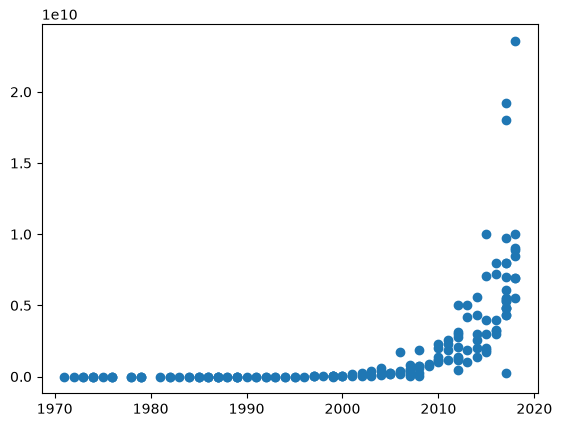

In [7]:
plt.scatter(data[0], data[1])

In [8]:
data = data.to_numpy()

In [12]:
X = data[:,0].reshape(-1,1) # Convert to 2D array
y = data[:,1]

In [14]:
print(X.shape, y.shape)

(162, 1) (162,)


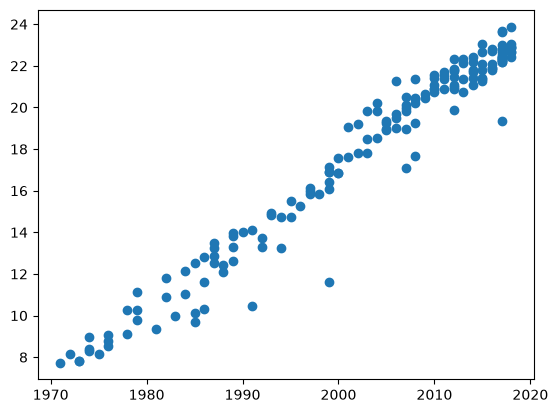

In [15]:
y = np.log(y) # Take the log of y
plt.scatter(X, y)

In [16]:
X = X - X.mean() # Center the data

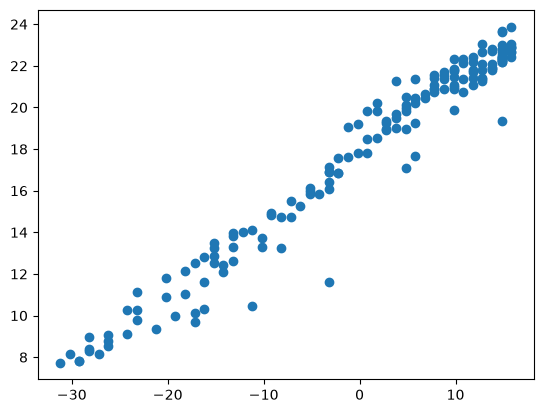

In [17]:
plt.scatter(X, y)

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(0.001, 0.9),   # Gradient descent momentum learning rate, momentum rate
    loss='mse',
    metrics=["accuracy"]
)

In [21]:
def schedule(epoch, lr):
    if epoch >= 50:
        return 0.0001
    return 0.001

scheduler = tf.keras.callbacks.LearningRateScheduler(schedule)

In [22]:
r = model.fit(X, y, epochs=200, callbacks=scheduler)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0000e+00 - loss: 429.9116 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 344.9455 - learning_rate: 0.0010
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 283.2038 - learning_rate: 0.0010
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 189.8615 - learning_rate: 0.0010
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 161.1085 - learning_rate: 0.0010
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 126.2131 - learning_rate: 0.0010
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 85.7860 - learning_rate: 0.0010
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 70.9169 - learning_rate: 0.0010
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 51.9075 - learning

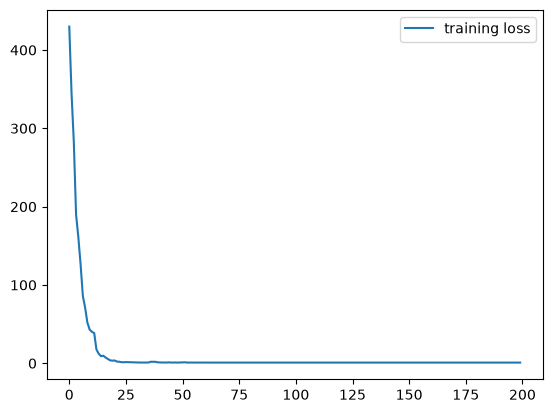

In [23]:
plt.plot(r.history['loss'], label = 'training loss')
plt.legend()

In [27]:
model.layers

[<Dense name=dense, built=True>]

In [31]:
model.layers[0].get_weights()

[array([[0.34094915]], dtype=float32), array([17.767448], dtype=float32)]

In [34]:
w1 = model.layers[0].get_weights()[0][0,0]
w1

np.float32(0.34094915)

In [38]:
b1 = model.layers[0].get_weights()[1][0]
b1

np.float32(17.767448)